# Background evolution of the field with CLASS

The goal of this program is to plot the evolution in redshift $z$ of the axion field $\chi_0$. The equation of motion is $$ \chi_0''+2\mathcal{H}\chi_0'+a(\tau)^2\frac{dV}{d\chi_0}=0\, , $$ where $'=\frac{d}{d\tau}$ and $\mathcal{H}$ is the Hubble ratio in conformal time. In this case I tried using CLASS to compute the evolution of $a(\tau)$ and and $\mathcal{H}(a)$.
As before I imported all the necessary libraries, including Classy for CLASS.

In [21]:
import classy as cl
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In this case I only need to explicitly define $M_{Pl}$ and $m_{Pl}$ since the other cosmological parameters will be define inside CLASS.

In [22]:
ev_to_Mpc=1.5637e29
Mpl=1.22e28*ev_to_Mpc
mpl=Mpl/np.sqrt(8*np.pi)

Now I finally use CLASS to obtain the evolution of different quantities depending on the cosmological parameters that I input. I printed the first line of these quantities so that I could see how the program calls what I am interested in, in this case just $z$, $\tau$, $a(\tau)$ and $H$.

In [23]:
cosmo=cl.Class()
parameters={'h':0.6736, 'omega_b':0.02237, 'omega_cdm':0.12, 'A_s':2.1e-9, 'n_s':0.965, 'tau_reio':0.054}
cosmo.set(parameters)
cosmo.compute()
bg=cosmo.get_background()
print(bg.keys())

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])


I extract the quantities mentioned before and transform $H$ into $\mathcal{H}$ by multiplying it by $a$.

In [24]:
tau=np.array(bg['conf. time [Mpc]'])
z=np.array(bg['z'])
a=np.array(1/(1+z))
H=np.array(bg['H [1/Mpc]'])
H_conformal=a*H

To compute the EOM i need to interpolate the points given by CLASS because *ScyPy* will require more points and much closer to each other to compute the differential equation.  After I also need to write, as in the other case, the derivative of the potential for the differential equation.

In [25]:
a_func_tau=sp.interpolate.interp1d(tau, a)
H__func_tau=sp.interpolate.interp1d(tau, H_conformal)

def V(x0, mx):
    return Mpl**2*mx**2*(1-np.cos(x0/Mpl))**2
def V_prime(x0, mx):
    return 2*Mpl*mx**2*np.sin(x0/Mpl)*(1-np.cos(x0/Mpl))
def eom(tau, y, mx):
    x0, vx=y
    return [vx, -2*H__func_tau(tau)*vx-a_func_tau(tau)**2*V_prime(x0, mx)]

From here the computation is very similar to the other scenario. I just need to input everything computed up to now in my differetial equation calculator, find $\chi_0(\tau)$ for each value of $m_\chi$ and then convert it into $\chi_0(z)$ for the plot.

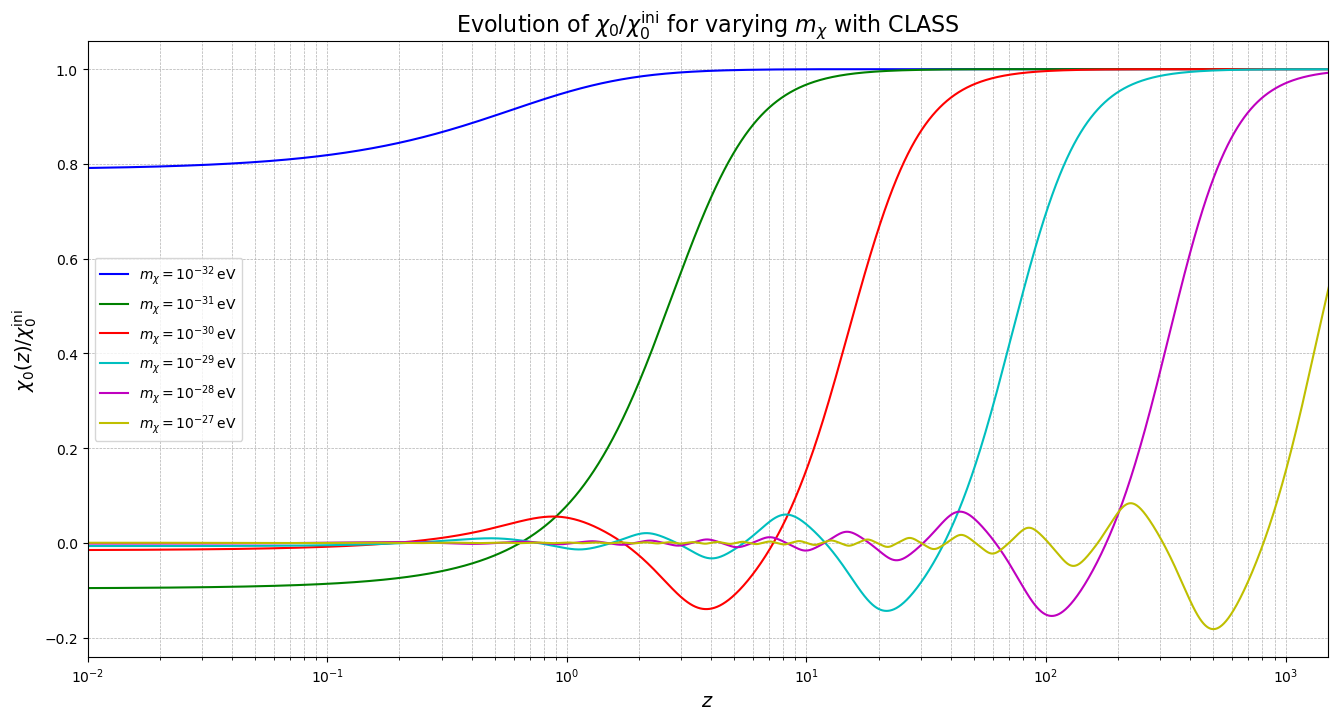

In [33]:
mx_values_Mpc=np.logspace(-32, -27, 6)*ev_to_Mpc
mx_values=[1e-32, 1e-31, 1e-30, 1e-29, 1e-28, 1e-27]

def LaTex_mass(mx_values):
    exp = int(np.log10(mx_values))
    return rf'10^{{{exp}}}\,\mathrm{{eV}}'

colors=['b', 'g', 'r', 'c', 'm', 'y']

plt.figure(figsize=(16, 8))
plt.xscale('log')

for mx_Mpc, mx, col in zip(mx_values_Mpc, mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)
    x0_solution=solution.sol(tau)[0]/initial_conditions[0]

    plt.plot(z, x0_solution, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$')
    



plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 1500)
plt.ylabel(r'$\chi_0(z)/ \chi_0^{\mathrm{ini}}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\chi_0/\chi_0^{\rm ini}$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show()

The small differences between this case and the other in which I computed the evolution of the cosmological functions $a(\tau)$ and $\mathcal{H}$ are given by the small inaccuracies that the different numerical integrations carry with them. Overall the graphs have the same exact features and show the same exact evolution for the different masses given, and, most important, they match the ones in the paper "Probing Axions through Tomography of Anisotropic Cosmic Birefringence". 

Moreover, it is possible to compute the value of $\omega_{\chi_0}$, i.e. the ratio of the equation of state of $\chi_0$. To do so I can simply take the second result given by the integration of the equation of motion, $\chi_0'(\tau)=v_{\chi_0}$, and using the formula $$ \omega_{\chi_0}=\frac{\chi_0'-2a^2V(\chi_0)}{\chi_0'+2a^2V(\chi_0)}\, ,$$ we get the evolution of omega in redshift. 

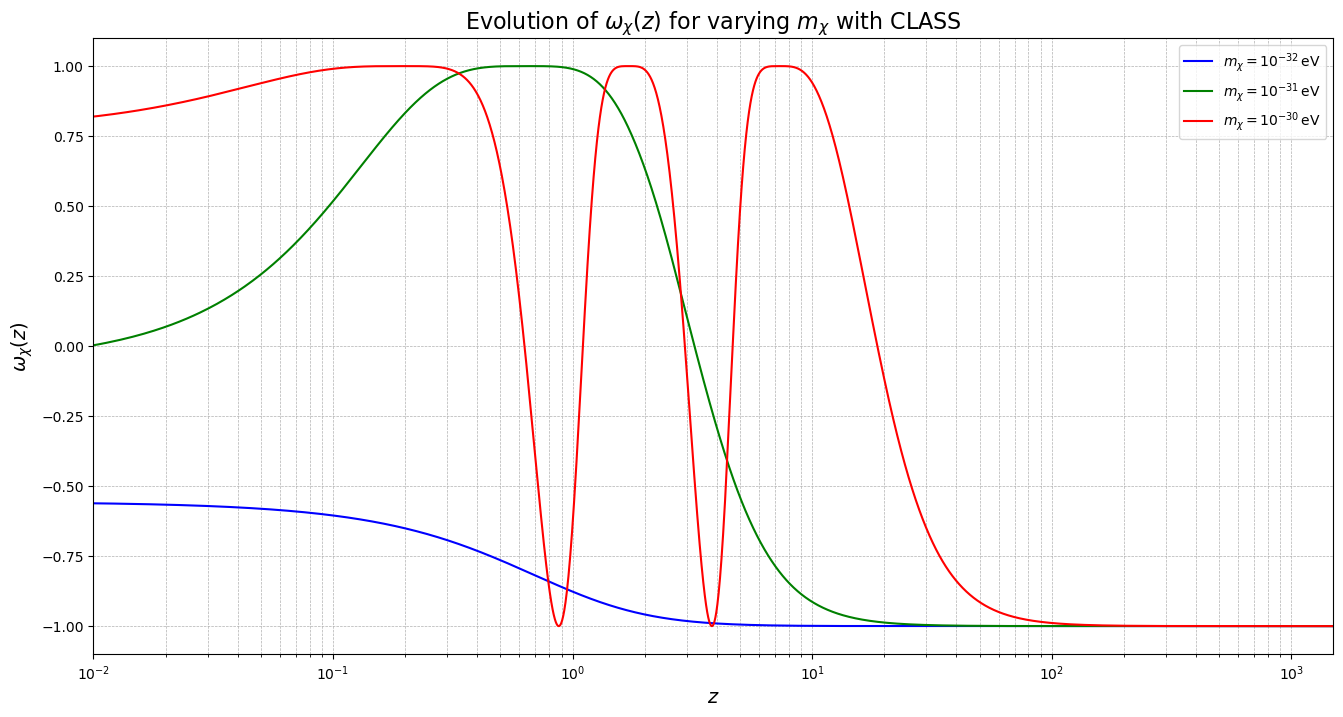

In [34]:
plt.figure(figsize=(16, 8))
plt.xscale('log')

mx_values_Mpc=np.logspace(-32, -30, 3)*ev_to_Mpc
for mx_Mpc, mx, col in zip(mx_values_Mpc, mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)

    vx_solution=solution.sol(tau)[1]
    omega=(vx_solution**2-2*a_func_tau(tau)**2*V(solution.sol(tau)[0], mx_Mpc))/(vx_solution**2+2*a_func_tau(tau)**2*V(solution.sol(tau)[0], mx_Mpc))
    plt.plot(z, omega, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$') 


plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 1500)
plt.ylabel(r'$\omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\omega_\chi(z)$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show() 